# Heatbudget AREA1 Clim
## Module 导入 与 常量生成

In [6]:
import os
import datetime
import numpy as np
import scipy as sp
import pandas as pd
import netCDF4 as nc
import PIL.Image as Image
import cartopy.crs as ccrs
import marineHeatWaves as mhw
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from datetime import date
from tqdm import notebook
from scipy.stats import pearsonr
from matplotlib.backends.backend_agg import FigureCanvasAgg
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor


In [3]:

# 时间
time=pd.date_range('2021-7-1','2021-9-30')
time_a=pd.date_range('1993-1-1','2019-12-31',freq='1D')
t= np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal()+1)
# 空间
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')[-1::-1]
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
# 空间切割
## are1
area1_lat=(lat_4>=35)&(lat_4<=50)
area1_lon=(lon_4>=195)&(lon_4<=230)
## area2
area2_lat=(lat_4>=22.5)&(lat_4<=42.5)
area2_lon=(lon_4>=165)&(lon_4<=210)

## Climatology 计算函数
此函数适用于一维数据的气候态计算

In [2]:
def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]
    return ts

def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0]
        tempClim = alternateClimatology[1]
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy() 
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]


## $Q$ 表面净热通量总和

### Functions

$$
Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}
$$
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{\frac{h}{0.35}}+0.42e^\frac{h}{23})$
- $\rho _{0}: 1.024 g/cm^{3}$
- $C_{p}: 3850 J\cdot kg^{-1} \cdot C^{-1}$
- *h*为*MLD*，*混合层深度* 与**海表温差2℃**

### Data list

- *h*(MLD)
  - [depth](/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy)
  - [thetao](/lustre/home/yuhanxue/data/heatbudgetV2/tos.npy)
- $Q_{ShortwaveRadiation}$ 
  - [ssrs](/lustre/home/yuhanxue/data/heatbudgetV2/ssrs_a.npy)
- $Q_{LongwaveRadiation}$ 
  - [strs](/lustre/home/yuhanxue/data/heatbudgetV2/strs_a.npy)
- $Q_{LatentHeatFlux}$ 
  - [slhf](/lustre/home/yuhanxue/data/heatbudgetV2/sshfs_a.npy)
- $Q_{SensibleHeatFlux}$ 
  - [sshf](/lustre/home/yuhanxue/data/heatbudgetV2/sshfs_a.npy)

### 计算1993-2019 MLD 区域1

In [4]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld_area1(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map_area1(dat):
    ans=np.array(list(map(mld_area1,dat)))
    return ans
def onetime_area1(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map_area1,a)))
    return ans
pool = ProcessPoolExecutor(max_workers=72)
thetaos_a=np.load('/lustre/home/yuhanxue/data/heatbudgetV2/tos.npy')
thetaos_area1_a=thetaos_a[:,:,area1_lat,:][:,:,:,area1_lon]
mld2021_a1=np.array(list(pool.map(onetime_area1,thetaos_area1_a)))
del pool
np.save('/lustre/home/yuhanxue/data/heatbudgetV2/mld__a1_27years.npy',mld2021_a1)

In [20]:
mld2021_a1=np.load('/lustre/home/yuhanxue/data/heatbudgetV2/mld__a1_27years.npy')

In [13]:
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/time.npy",allow_pickle=True))
time2021ind=(times.year<=2019)
msnlwrfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnlwrfs.npy')[time2021ind]#LongwaveRadiation
msnswrfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnswrfs.npy')[time2021ind]#ShortwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_mslhfs.npy')[time2021ind]#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msshfs.npy')[time2021ind]#SensibleHeatFlux
del times,time2021ind

### 计算公式
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{-\frac{h}{0.35}}+0.42e^{-\frac{h}{23}})$
- $Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}$

In [17]:
Q_net=msnswrfs_2021+msnlwrfs_2021+slhfs_2021+sshfs_2021
Q_z=msnswrfs_2021*(0.58*np.exp(-1*mld2021_a1/0.35)+0.42*np.exp(-1*mld2021_a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021_a1)*24*3600

### Clim 计算

In [18]:
def clim_cal(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal()+1)
    return np.array(Clim(t,dat))
def clim_map(dat):
    pool = ProcessPoolExecutor(max_workers=9)
    ans=np.array(list(pool.map(clim_cal,dat)))
    del pool
    return ans
def clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=8)
    ans=np.array(list(pool.map(clim_map,a)))
    del pool
    return ans
Q_area1_a_clim=clim_allinone(Q)

Text(0.5, 1.0, 'Q area1 clim')

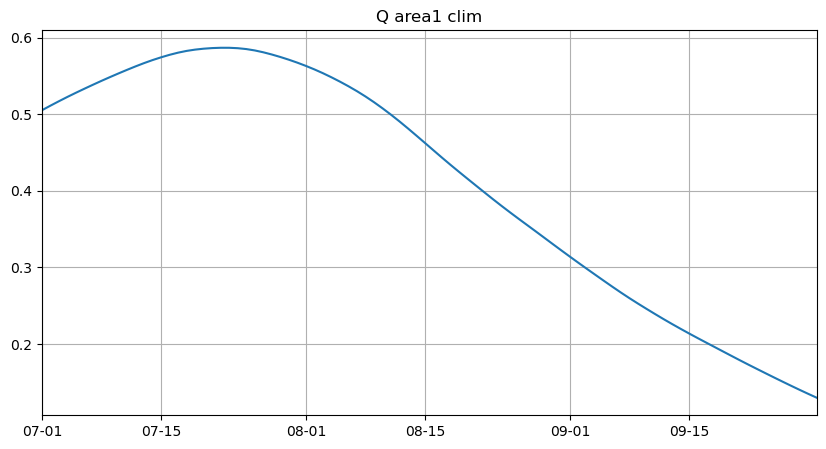

In [19]:
from matplotlib.dates import DateFormatter, MONDAY, MonthLocator, YearLocator
formatter = DateFormatter('%m-%d')
plt.figure(figsize=[10,5])
ind=(time_a.year==2019)&((time_a.month==7)|(time_a.month==8)|(time_a.month==9))
plt.plot(time_a[ind],np.nanmean(np.nanmean(Q_area1_a_clim[:,:,ind],axis=0),axis=0))
#plt.plot(time_a[ind],[0]*time_a[ind].shape[0],'r')
plt.xlim(time_a[ind][0],time_a[ind][-1])
ax=plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Q area1 clim')

## Mixed Layer Temperature Tendency

### Functions
$$
Mixed Layer Temperature Tendency=\frac{\mathrm{d}\mathrm{T_{m}}}{\mathrm{d}\mathrm{t}}
$$
- $\mathrm{T_{m}}$为$\mathrm{T_{0}}$至$\mathrm{T_{-h}}$的平均值

### 计算tm&mltt

In [21]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat): 
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    ans=np.array(list(map(tm,dat)))
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map2,a)))
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=72)
tms_area1_a=np.array(list(pool.map(onetime2,thetaos_area1_a)))
del pool
mltt_area1_a=tms_area1_a[1:,:,:]-tms_area1_a[:-1,:,:]
np.save('/lustre/home/yuhanxue/data/heatbudgetV2/mltt_area1_a.npy',mltt_area1_a)

### Clim 计算

In [22]:
def clim_cal(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal())
    return np.array(Clim(t,dat))
def clim_map(dat):
    pool = ProcessPoolExecutor(max_workers=9)
    ans=np.array(list(pool.map(clim_cal,dat)))
    del pool
    return ans
def clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=8)
    ans=np.array(list(pool.map(clim_map,a)))
    del pool
    return ans
mltt_area1_a_clim=clim_allinone(mltt_area1_a)

Text(0.5, 1.0, 'mltt area1 clim')

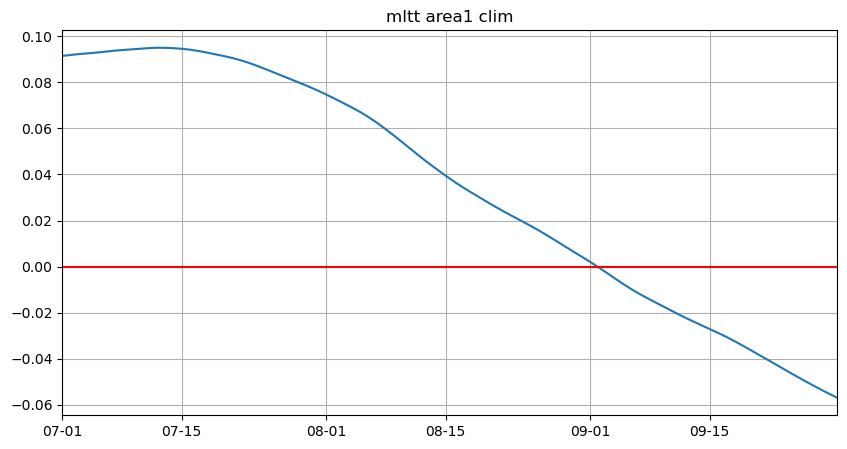

In [23]:
from matplotlib.dates import DateFormatter, MONDAY, MonthLocator, YearLocator
formatter = DateFormatter('%m-%d')
plt.figure(figsize=[10,5])
ind=(time_a.year==2019)&((time_a.month==7)|(time_a.month==8)|(time_a.month==9))
plt.plot(time_a[ind],np.nanmean(np.nanmean(mltt_area1_a_clim[:,:,ind[:9860]],axis=0),axis=0))
plt.plot(time_a[ind],[0]*time_a[ind].shape[0],'r')
plt.xlim(time_a[ind][0],time_a[ind][-1])
ax=plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.grid()
plt.title('mltt area1 clim')

## HADV 水平平流项
### Functions
$$
HADV=-\overrightarrow{U_{m}}\bigtriangledown T_{m}=-(u_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}x}+v_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}y})
$$
- $ \overrightarrow{U_{m}} $为0~h平均水平速度
- $T_{m}$为0~-h深度的平均位温
- $u_{m}$为水平经向速度
- $v_{m}$为水平纬向速度
- 注：纬度长度不固定，需要进行修正，修正公式:$111(Δ lon)\cdot cos(lat)$
### Data list
- uos
- vos
- tm
- lon_4
- lat_4

In [24]:
uos=np.load("/lustre/home/yuhanxue/data/heatbudgetV2/uos.npy")*3600*24
vos=np.load("/lustre/home/yuhanxue/data/heatbudgetV2/vos.npy")*3600*24
uos_area1_a=uos[:,:,area1_lat,:][:,:,:,area1_lon]
vos_area1_a=vos[:,:,area1_lat,:][:,:,:,area1_lon]
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')

lat_4 range:35.00~50.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


### 计算$u_{m}$、$v_{m}$、经向&纬向积分、HADV


In [25]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    return np.array(list(map(tm,dat)))
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map2,dat)))
    #ans=np.array(list(map(list_map2,dat)))
    return ans

def ms(dat):
    global thetaos_area1_a
    pool = ProcessPoolExecutor(max_workers=72)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos_area1_a]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(uos_area1_a)
vm=ms(vos_area1_a)

dx=np.array([(tms_area1_a[:,i,1:]-tms_area1_a[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms_area1_a[:,1:,:]-tms_area1_a[:,:-1,:])/(111e3/4)

hadv_area1_a=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

In [26]:
def clim_cal(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal()+1)
    return np.array(Clim(t,dat))
def clim_map(dat):
    pool = ProcessPoolExecutor(max_workers=9)
    ans=np.array(list(pool.map(clim_cal,dat)))
    del pool
    return ans
def clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=8)
    ans=np.array(list(pool.map(clim_map,a)))
    del pool
    return ans
hadv_area1_a_clim=clim_allinone(hadv_area1_a)

Text(0.5, 1.0, 'hadv area1 clim')

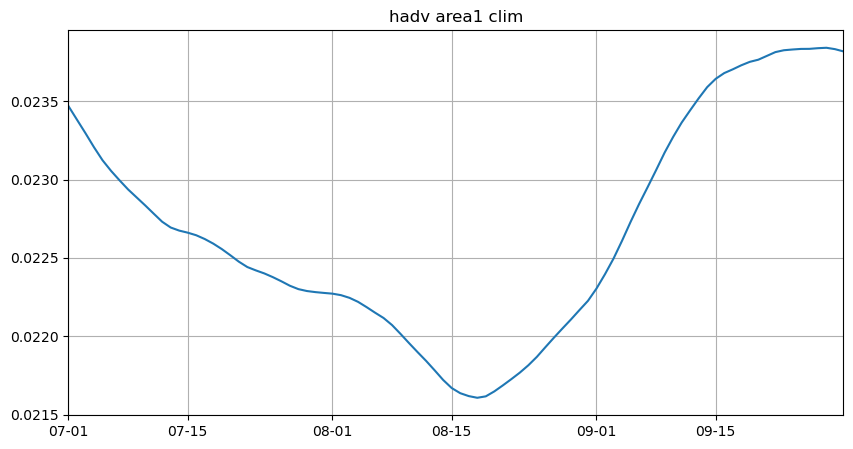

In [27]:
from matplotlib.dates import DateFormatter, MONDAY, MonthLocator, YearLocator
formatter = DateFormatter('%m-%d')
plt.figure(figsize=[10,5])
ind=(time_a.year==2019)&((time_a.month==7)|(time_a.month==8)|(time_a.month==9))
plt.plot(time_a[ind],np.nanmean(np.nanmean(hadv_area1_a_clim[:,:,ind[:9861]],axis=0),axis=0))
#plt.plot(time_a[ind],[0]*time_a[ind].shape[0],'r')
plt.xlim(time_a[ind][0],time_a[ind][-1])
ax=plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.grid()
plt.title('hadv area1 clim')

Text(0.5, 1.0, 'hadv area1 2019-07~2019-09')

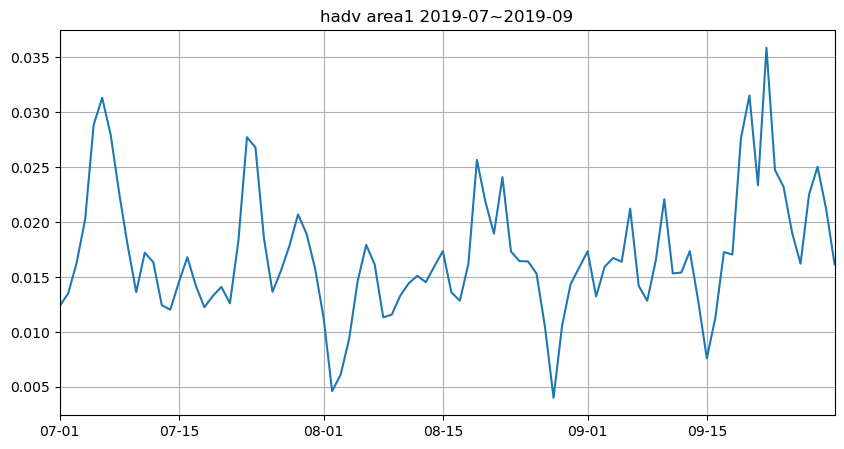

In [28]:
from matplotlib.dates import DateFormatter, MONDAY, MonthLocator, YearLocator
formatter = DateFormatter('%m-%d')
plt.figure(figsize=[10,5])
ind=(time_a.year==2019)&((time_a.month==7)|(time_a.month==8)|(time_a.month==9))
plt.plot(time_a[ind],np.nanmean(np.nanmean(hadv_area1_a[ind[:9861],:,:],axis=-1),axis=-1))
#plt.plot(time_a[ind],[0]*time_a[ind].shape[0],'r')
plt.xlim(time_a[ind][0],time_a[ind][-1])
ax=plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.grid()
plt.title('hadv area1 2019-07~2019-09')

In [23]:
np.savez("/lustre/home/yuhanxue/data/heatbudgetV2/area1_07~09_mltt_Q_HADV_clim.npz",mltt_area1_a_clim=mltt_area1_a_clim[:,:,ind[:9860]],Q_area1_a1_clim=Q_area1_a_clim[:,:,ind],HADV=hadv_area1_a_clim[:,:,ind[:9861]])

## OVMIX

In [29]:
ovmix_area1_a=mltt_area1_a[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv_area1_a[:-1,:,:]

In [ ]:
def clim_cal(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal())
    return np.array(Clim(t,dat))
def clim_map(dat):
    pool = ProcessPoolExecutor(max_workers=9)
    ans=np.array(list(pool.map(clim_cal,dat)))
    del pool
    return ans
def clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=8)
    ans=np.array(list(pool.map(clim_map,a)))
    del pool
    return ans
ovmix_area1_a_clim=clim_allinone(ovmix_area1_a)

## SAVE

In [ ]:
np.savez("/lustre/home/yuhanxue/data/heatbudgetV2/area1_07~09_mltt_Q_HADV_clim.npz",mltt_area1_a_clim=mltt_area1_a_clim[:,:,ind[:9860]],Q_area1_a1_clim=Q_area1_a_clim[:,:,ind],HADV_area1_a_clim=hadv_area1_a_clim[:,:,ind[:9861]],ovmix_area1_a_clim=ovmix_area1_a_clim[:,:,ind[:9860]])